# Get Started with Flower

## Introduction

Flower (```flwr```) is a framework used to build Federated Learning systems. It was created with the mind of customizability, extendability, adapting with multiple machine learning framework, but easily understandable to provide desirable maintainability for its users.

To proceed, we install the necessary modules via pip, including flower itself, the machine learning framework we will be using and others:

In [1]:
!pip install -q 'flwr[simulation]' 'flwr_datasets[vision]' torch torchvision matplotlib numpy, scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.0/235.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 28.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 34.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 85.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 51.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 MB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 40.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 16.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 17.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.14.0 requires protobuf<4.21,>=3.20.3, but you have protobuf 4.25.3 whic

Then, we import the modules:

In [26]:
from collections import OrderedDict
from typing import List, Tuple, Dict, Optional, Union, Callable

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from datasets.utils.logging import disable_progress_bar
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10

import flwr as fl
from flwr.common import Metrics
from flwr_datasets import FederatedDataset
from flwr.common import (
    EvaluateIns,
    EvaluateRes,
    FitIns,
    FitRes,
    MetricsAggregationFn,
    NDArrays,
    Parameters,
    Scalar,
    ndarrays_to_parameters,
    parameters_to_ndarrays,
)
from flwr.server.client_manager import ClientManager
from flwr.server.client_proxy import ClientProxy
from flwr.server.strategy.aggregate import aggregate, weighted_loss_avg

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


To see where this machine learning is running on:

In [3]:
DEVICE = torch.device("cuda")  # If GPU available, use "cuda?, if not available or any errors, change to "cpu" to use CPU
print (f"Train on {DEVICE} using Pytorch {torch.__version__} and Flower {fl.__version__}")
disable_progress_bar();

Train on cuda using Pytorch 2.1.0+cu121 and Flower 1.7.0


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


## Loading Data

In this notebook, we are going to train an image classifiers on a dataset CIFAR-10, the model after training should be able to classify objects in the image, such as airplane, dogs or trucks.

In real-life scenario, a huge dataset is always to gluing outcome of multiple smaller datasets from different entities. This is also the case from Federated Learning, there is no transfer on data, there is no chance of them to sit in a large database. Of course they could also play the role of different collaborators, trying to utilise machine learning techniques but having solid data security concerns or regulations, making them unwilling to share the data.

Now we will import the data and slice it:

In [4]:
NUM_CLIENTS = 10
BATCH_SIZE = 32

def load_datasets():
  dataset_federated = FederatedDataset(
      dataset="cifar10",
      partitioners={"train": NUM_CLIENTS}
      )

  def apply_transforms(batch):
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
        ]
    )
    batch["img"] = [transform(img) for img in batch["img"]]
    return batch

  trainloaders = []
  valloaders = []
  for partition_id in range(NUM_CLIENTS):
    partition = dataset_federated.load_partition(partition_id, "train")
    partition = partition.with_transform(apply_transforms)
    partition = partition.train_test_split(train_size=0.8)
    trainloaders.append(DataLoader(partition["train"], batch_size=BATCH_SIZE))
    valloaders.append(DataLoader(partition["test"], batch_size=BATCH_SIZE))
  testset = dataset_federated.load_full("test").with_transform(apply_transforms)
  testloader = DataLoader(testset, batch_size=BATCH_SIZE)
  return trainloaders, valloaders, testloader

trainloaders, valloaders, testloader = load_datasets()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


What the snippet above did is to create 10 training sets and 10 validation sets, respectively ```trainloaders``` and ```valloaders```. representing 10 different organisatiosn let's say. Each of this "organisation" will pair 4500 training examples from the "trainloader" and 500 validation examples from the "valloader".

There is also a complete set of data as ```testloader```.

Now, we inspect the data see if things are getting in:

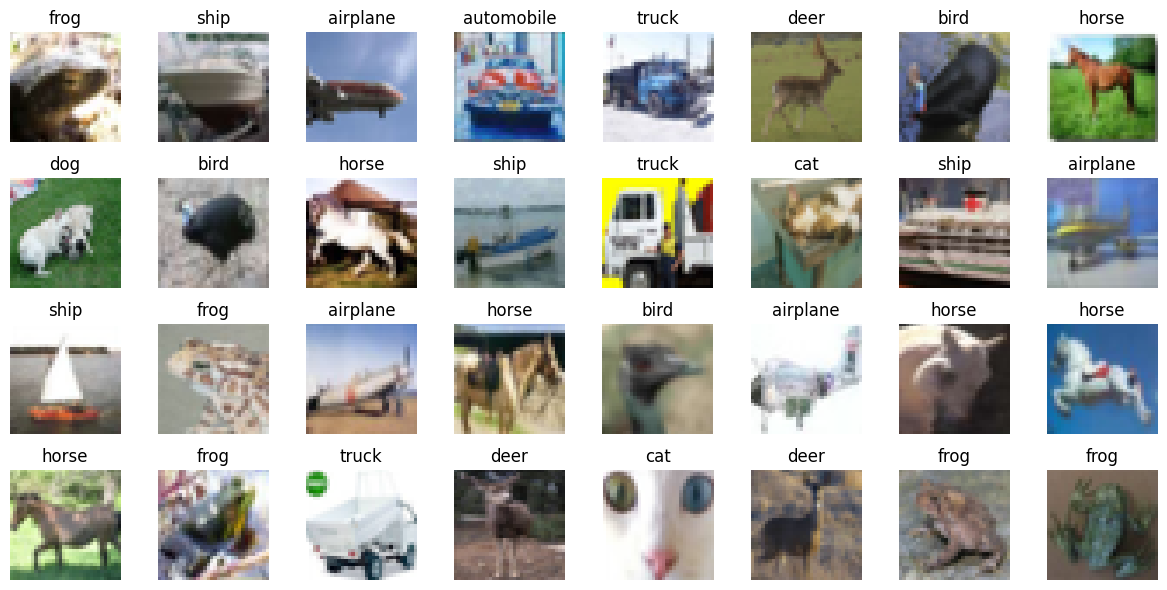

In [5]:
batch = next(iter(trainloaders[0]))
images, labels = batch["img"], batch["label"]

# Now we change this to a numpy array, matplotlib will require it as (h, w, 3)
images = images.permute(0,2,3,1).numpy()

images = images / 2 + 0.5

# Create Visual

fig, axs = plt.subplots(4,8,figsize=(12,6))

for i,ax in enumerate(axs.flat):
  ax.imshow(images[i])
  ax.set_title(trainloaders[0].dataset.features["label"].int2str([labels[i]])[0])
  ax.axis("off")
fig.tight_layout()
plt.show()

## Centralised Machine Learning

So first we will just do this with PyTorch simply, just like the old application of centralised machine learing.

### Define the Model

We use a Convolutional Neural Network, also known as CNN:

In [6]:
class Net(nn.Module):
  def __init__(self) -> None:
    super(Net, self).__init__()
    self.conv1 = nn.Conv2d(3,6,5)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(6,16,5)
    self.fc1 = nn.Linear(16 * 5 * 5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.view(-1, 16 * 5 * 5)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

# train() and test()

def train(net, trainloader, epochs: int, verbose=False):
  criterion = torch.nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(net.parameters())
  net.train()
  for epoch in range(epochs):
    correct,total,epoch_loss = 0, 0, 0.0
    for batch in trainloader:
      images, labels = batch["img"].to(DEVICE), batch["label"].to(DEVICE)
      optimizer.zero_grad()
      outputs = net(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      epoch_loss += loss
      total += labels.size(0)
      correct += (torch.max(outputs.data, 1)[1] == labels).sum().item()
    epoch_loss /= len(trainloader.dataset)
    epoch_acc = correct / total
    if verbose:
      print(f"Epoch {epoch+1}: train_loss {loss} accuracy {accuracy}")

def test(net, testloader):
  criterion = torch.nn.CrossEntropyLoss()
  correct, total, loss = 0, 0, 0.0
  net.eval()
  with torch.no_grad():
    for batch in testloader:
      images, labels = batch["img"].to(DEVICE), batch["label"].to(DEVICE)
      outputs = net(images)
      loss += criterion(outputs, labels).item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  loss /= len(testloader.dataset)
  accuracy = correct / total
  return loss, accuracy

### Train the Model

Now we train the model, but this time we only use one organisation ```trainloaders[0]``` and ```valloaders[0]```.

In [7]:
trainloader = trainloaders[0]
valloader = valloaders[0]
net = Net().to(DEVICE)

for epoch in range(5):
  train(net,trainloader, 1)
  loss, accuracy = test(net, valloader)
  print(f"Epoch {epoch+1}: Validation Loss: {loss}, Accuracy: {accuracy}")

loss, accuracy = test(net, testloader)
print(f"Final test set performance:\n\tLoss: {loss}\n\tAccurary: {accuracy}")

Epoch 1: Validation Loss: 0.0625726010799408, Accuracy: 0.29
Epoch 2: Validation Loss: 0.05829465270042419, Accuracy: 0.355
Epoch 3: Validation Loss: 0.05509098732471466, Accuracy: 0.379
Epoch 4: Validation Loss: 0.05270409548282623, Accuracy: 0.41
Epoch 5: Validation Loss: 0.050862467288970946, Accuracy: 0.435
Final test set performance:
	Loss: 0.04983417594432831
	Accurary: 0.4141


Now you just tried your first machine learning pipeline. Congrats! The accuracy obviously is not all time high, but it's fine.

## Flower: Federated Learning

In the learning before, we just used one "organisation" (```trainloaders[0]``` and ```valloaders[0]```). Now we will actually deploy Federated Learning, making this machine learning actually go accross multiple "organisations".

### Update Model Parameters

In Federated Learning, the global server firstly sends the Global Model's Parameters to each client, then the client will update the local model with the parameters by training the model with its local data. Then the updated model with new parameters will be sent back to the server, or actually the gradients back to the global server instead of full model parameters.

To achieve this, we need to helper functions ```set_parameters()``` and ```get_parameters()``` for the client to use. The parameters will be retrieved from the tensors as dicts, then converted into a list of numpy ndarrays, which Flower can serialise and deseriliase.

In [8]:
def set_parameters(net, parameters: List[np.ndarray]) -> None:
  params_dict = zip(net.state_dict().keys(), parameters)
  state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
  net.load_state_dict(state_dict, strict=True)

def get_parameters(net) -> List[np.ndarray]:
  return [val.cpu().numpy() for _, val in net.state_dict().items()]

### Implement Flower Client

A Federated Learning Framework consists a shared global server for model aggregation and update and multiple clients for model training. In Flower, how you create each of those clients is to implement subclass of built-in classes in Flower ```flwr.client.Client()``` or ```flwr.client.NumPyClient```, and this subclass implement 3 key functions:

* ```get_parameters```: Return current Local Model's Parameters.
* ```fit```:
  * Receive Global Model Parameters from the server.
  * Train the Model Parameters with local data.
  * Return the Updated Local Parameters to the server.
* ```evaluate```:
  * Receive Update Global Model Parameters from the server.
  * Evaluate the Model Parameters with local data.
  * Return the evaluation result to the server.

We can just use our functions defined previously when we are demostrating PyTorch with centralised machine learning:

In [9]:
class FlowerClient(fl.client.NumPyClient):
  def __init__(self, net, trainloader, valloader):
    self.net = net
    self.trainloader = trainloader
    self.valloader = valloader

  def get_parameters(self, config):
    return get_parameters(self.net)

  def fit(self, parameters, config):
    set_parameters(self.net, parameters)
    train(self.net, self.trainloader, epochs=1)
    return get_parameters(self.net), len(self.trainloader), {}

  def evaluate(self, parameters, config):
    set_parameters(self.net, parameters)
    loss, accuracy = test(self.net, self.valloader)
    return float(loss), len(self.valloader), {"accuracy": float(accuracy)}

From now then on, each client in our Federated Learning Framework is an instance of this class.

### Use Virtual Client Engine

If we have 10 clients, normally it would mean that we have 10 devices with their own hardwares to run the client-side jobs. However, here we are trying to simulate this in one device, this could be resource-consuming as all clients are sharing the same hardware with each other on the same machine.

To avoid this resource blackhole, we can utilise Flower's special simulation capacities to create clients on demand: they will only be created when necessary and they will be discarded after use when no longer needed without any local state kept.

Here, ```client_fn(cid: str)``` is the function used here that whenever a client needs to be created, Flower will call this function and whenever it needs a instance of one particular client to use ```fit()``` and ```evaluate()```. The identification is done by client ID.

In [10]:
def client_fn(cid: str) -> FlowerClient:
  return FlowerClient(
    Net().to(DEVICE),
    trainloaders[int(cid)],
    valloaders[int(cid)]
  ).to_client()

### Accuracy

If we just go set the train now, we won't be able to find the accuracy. Flower can automatically aggregate losses from individual clients, but not the same for metrics in the generic metrics dictionary \(the one with the accuracy key\). The metrics dictionaries can contain very different kinds of metrics and even k/v pairs that are not metrics at all. This leads to the framework has no idea how to handle these automatically.

As the users we need to tell the framework to handle/aggregate these custom metrics, we do this by passing the metric aggregatin fuctions into the strategy as parameter, possibly ```fit_metrics_aggregation_fn``` and ```evaluate_metrics_aggregation_fn```, the strategy will then call the function whenever it receives fit or evaluate metrics from clients.

In [11]:
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
  # Accuracy of Each Client * Number of Examples
  accus = [num_examples * m["accuracy"] for num_examples, m in metrics]
  examples = [num_examples for num_examples, _ in metrics]

  return {"accuracy": sum(accus) / sum(examples)}

### De Train

Now we have everything prepared, it's time to train, with ```flwr.simulation.start_simulation()```.

Just like before, this function accepts numerous variables, including the ```client_fn``` to create ```FlowerClient``` instances, number of clients, number of rounds, and the strategy, which is the Federated Learning Algorithm/Approach we are using here - Federated Averaging, here it encapsulates the built-in  strategies ```fl.server.strategy.FedAvg```, where of course, you can pass some parameters in to customize your strategy a bit:

In [12]:
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0, # Sample 100% of the clients for training
    fraction_evaluate=0.5, # Sample 50% of the clients for evaluation
    min_fit_clients=10, # Never Sample less than 10 clients
    min_evaluate_clients=5, # Never sample less than 5 clients for evaluation
    min_available_clients=10, # Wait until all 10 clients are available
    # Pass the metric aggregation function
    evaluate_metrics_aggregation_fn=weighted_average,
)

client_resources = {"num_cpus": 1, "num_gpus": 0.0}
if DEVICE.type == "cuda":
  client_resources = {"num_cpus": 1, "num_gpus": 1.0}

fl.simulation.start_simulation(
    client_fn=client_fn, # How to call Clients?
    num_clients=NUM_CLIENTS, # How many Clients should be there?
    config=fl.server.ServerConfig(num_rounds=5), # How many rounds?
    strategy=strategy, # How to use these clients?
    client_resources=client_resources, # What hardware are we on?
)

INFO flwr 2024-03-06 11:05:18,196 | app.py:178 | Starting Flower simulation, config: ServerConfig(num_rounds=5, round_timeout=None)
INFO:flwr:Starting Flower simulation, config: ServerConfig(num_rounds=5, round_timeout=None)
2024-03-06 11:05:22,155	INFO worker.py:1621 -- Started a local Ray instance.
INFO flwr 2024-03-06 11:05:23,719 | app.py:213 | Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'node:__internal_head__': 1.0, 'memory': 7823791719.0, 'object_store_memory': 3911895859.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0}
INFO:flwr:Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'node:__internal_head__': 1.0, 'memory': 7823791719.0, 'object_store_memory': 3911895859.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0}
INFO flwr 2024-03-06 11:05:23,727 | app.py:219 | Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html
INFO:flwr:Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html


History (loss, distributed):
	round 1: 0.06663277118206024
	round 2: 0.0564536824464798
	round 3: 0.052187344908714295
	round 4: 0.05115378198623658
	round 5: 0.04913399240970611
History (metrics, distributed, evaluate):
{'accuracy': [(1, 0.28359999999999996), (2, 0.35280000000000006), (3, 0.4022), (4, 0.40679999999999994), (5, 0.43599999999999994)]}

Congrats! You have just finished the most initial part of learning Flower.

Now, We are focusing on Strategy:

# Flower Strategies

## Data Loading and FlowerClient Refine

For this chapter, we use the CIFAR-10 training and test set, and we participate them into smaller datasets, to do this, ```load_datasets()``` is welcoming a new argument: ```num_clients: int```:

In [13]:
NUM_CLIENTS = 10 # Just to be sure

def load_datasets(num_clients: int):
  transform = transforms.Compose(
      [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
  )
  trainset = CIFAR10("./dataset", train=True, download=True, transform=transform)
  testset = CIFAR10("./dataset", train=False, download=True,transform=transform)

  # Partition the data to simulate different local clients
  partition_size = len(trainset) // num_clients
  lengths = [partition_size] * num_clients
  datasets = random_split(trainset, lengths, torch.Generator().manual_seed(42))

  trainloaders = []
  valloaders = []
  for ds in datasets:
    len_val = len(ds) // 10 # 10% validation set
    len_train = len(ds) - len_val
    lengths = [len_train, len_val]
    ds_train, ds_val = random_split(ds, lengths, torch.Generator().manual_seed(42))
    trainloaders.append(DataLoader(ds_train, batch_size=32, shuffle=True))
    valloaders.append(DataLoader(ds_val, batch_size=32))
  testloader = DataLoader(testset, batch_size=32)
  return trainloaders, valloaders, testloader

trainloaders, valloaders, testloader = load_datasets(NUM_CLIENTS)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


100%|██████████| 170498071/170498071 [00:01<00:00, 97870953.30it/s] 


Extracting ./dataset/cifar-10-python.tar.gz to ./dataset
Files already downloaded and verified


Then we will need to define the model, especially ```set_parameters()``` and ```get_parameters()```:

In [14]:
class Net(nn.Module):
    def __init__(self) -> None:
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


def get_parameters(net) -> List[np.ndarray]:
    return [val.cpu().numpy() for _, val in net.state_dict().items()]

def set_parameters(net, parameters: List[np.ndarray]):
    params_dict = zip(net.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
    net.load_state_dict(state_dict, strict=True)


def train(net, trainloader, epochs: int):
    """Train the network on the training set."""
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters())
    net.train()
    for epoch in range(epochs):
        correct, total, epoch_loss = 0, 0, 0.0
        for images, labels in trainloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(net(images), labels)
            loss.backward()
            optimizer.step()
            # Metrics
            epoch_loss += loss
            total += labels.size(0)
            correct += (torch.max(outputs.data, 1)[1] == labels).sum().item()
        epoch_loss /= len(trainloader.dataset)
        epoch_acc = correct / total
        print(f"Epoch {epoch+1}: train loss {epoch_loss}, accuracy {epoch_acc}")


def test(net, testloader):
    """Evaluate the network on the entire test set."""
    criterion = torch.nn.CrossEntropyLoss()
    correct, total, loss = 0, 0, 0.0
    net.eval()
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = net(images)
            loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    loss /= len(testloader.dataset)
    accuracy = correct / total
    return loss, accuracy

We have the data, model, now we need the client. Same as before, we create clients as subclass of ```flwr.client.NumPyClient``` and implement the three methods ```get_parameters()```, ```fit()```, and ```evaluate()```, and the client will also need an ID as ```cid``` argument:

In [15]:
class FlowerClient(fl.client.NumPyClient):
    def __init__(self, cid, net, trainloader, valloader):
        self.cid = cid
        self.net = net
        self.trainloader = trainloader
        self.valloader = valloader

    def get_parameters(self, config):
        print(f"[Client {self.cid}] get_parameters")
        return get_parameters(self.net)

    def fit(self, parameters, config):
        print(f"[Client {self.cid}] fit, config: {config}")
        set_parameters(self.net, parameters)
        train(self.net, self.trainloader, epochs=1)
        return get_parameters(self.net), len(self.trainloader), {}

    def evaluate(self, parameters, config):
        print(f"[Client {self.cid}] evaluate, config: {config}")
        set_parameters(self.net, parameters)
        loss, accuracy = test(self.net, self.valloader)
        return float(loss), len(self.valloader), {"accuracy": float(accuracy)}


def client_fn(cid) -> FlowerClient:
    net = Net().to(DEVICE)
    trainloader = trainloaders[int(cid)]
    valloader = valloaders[int(cid)]
    return FlowerClient(cid, net, trainloader, valloader)

## Strategy Customization

### Server-side Parameter Initialisation

Flower, by default, initialise the Global Model by asking one random client for the initial parameters, though in real life we will want to control during parameter initialisation. Flower allows you to pass initial parameters to the ```strategy```:

In [16]:
# Retrieve Parameters
params = get_parameters(Net())

# Apply Parameters
strategy = fl.server.strategy.FedAvg(
  fraction_fit=0.3,
  fraction_evaluate=0.3,
  min_fit_clients=3,
  min_evaluate_clients=NUM_CLIENTS,
  initial_parameters=fl.common.ndarrays_to_parameters(params),
)

# Prepare Resource
client_resources = None
if DEVICE.type == "cuda":
  client_resources = {"num_gpus": 1}

# Start Simulation
fl.simulation.start_simulation(
  client_fn=client_fn,
  num_clients=NUM_CLIENTS,
  config=fl.server.ServerConfig(num_rounds=3),
  client_resources=client_resources,
  strategy=strategy,
)

WARNING flwr 2024-03-06 11:07:31,886 | fedavg.py:118 | 
Setting `min_available_clients` lower than `min_fit_clients` or
`min_evaluate_clients` can cause the server to fail when there are too few clients
connected to the server. `min_available_clients` must be set to a value larger
than or equal to the values of `min_fit_clients` and `min_evaluate_clients`.

Setting `min_available_clients` lower than `min_fit_clients` or
`min_evaluate_clients` can cause the server to fail when there are too few clients
connected to the server. `min_available_clients` must be set to a value larger
than or equal to the values of `min_fit_clients` and `min_evaluate_clients`.

INFO flwr 2024-03-06 11:07:31,891 | app.py:178 | Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
INFO:flwr:Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
2024-03-06 11:07:36,151	INFO worker.py:1621 -- Started a local Ray instance.
INFO flwr 2024-03-06 11:07:38,290 

(DefaultActor pid=6480) [Client 3] fit, config: {}
(DefaultActor pid=6480) Epoch 1: train loss 0.0637100338935852, accuracy 0.23466666666666666
(DefaultActor pid=6480) [Client 9] fit, config: {}
(DefaultActor pid=6480) Epoch 1: train loss 0.06415751576423645, accuracy 0.24066666666666667
(DefaultActor pid=6480) [Client 6] fit, config: {}


DEBUG flwr 2024-03-06 11:07:55,017 | server.py:236 | fit_round 1 received 3 results and 0 failures
DEBUG:flwr:fit_round 1 received 3 results and 0 failures
WARNING flwr 2024-03-06 11:07:55,027 | fedavg.py:250 | No fit_metrics_aggregation_fn provided
DEBUG flwr 2024-03-06 11:07:55,030 | server.py:173 | evaluate_round 1: strategy sampled 10 clients (out of 10)
DEBUG:flwr:evaluate_round 1: strategy sampled 10 clients (out of 10)


(DefaultActor pid=6480) Epoch 1: train loss 0.0648740902543068, accuracy 0.23577777777777778
(DefaultActor pid=6480) [Client 0] evaluate, config: {}
(DefaultActor pid=6480) [Client 2] evaluate, config: {}
(DefaultActor pid=6480) [Client 3] evaluate, config: {}
(DefaultActor pid=6480) [Client 9] evaluate, config: {}
(DefaultActor pid=6480) [Client 5] evaluate, config: {}
(DefaultActor pid=6480) [Client 8] evaluate, config: {}
(DefaultActor pid=6480) [Client 4] evaluate, config: {}
(DefaultActor pid=6480) [Client 6] evaluate, config: {}
(DefaultActor pid=6480) [Client 1] evaluate, config: {}


DEBUG flwr 2024-03-06 11:08:13,568 | server.py:187 | evaluate_round 1 received 10 results and 0 failures
DEBUG:flwr:evaluate_round 1 received 10 results and 0 failures
WARNING flwr 2024-03-06 11:08:13,574 | fedavg.py:281 | No evaluate_metrics_aggregation_fn provided
DEBUG flwr 2024-03-06 11:08:13,576 | server.py:222 | fit_round 2: strategy sampled 3 clients (out of 10)
DEBUG:flwr:fit_round 2: strategy sampled 3 clients (out of 10)


...

DEBUG flwr 2024-03-06 11:08:49,426 | server.py:236 | fit_round 3 received 3 results and 0 failures
DEBUG:flwr:fit_round 3 received 3 results and 0 failures
DEBUG flwr 2024-03-06 11:08:49,436 | server.py:173 | evaluate_round 3: strategy sampled 10 clients (out of 10)
DEBUG:flwr:evaluate_round 3: strategy sampled 10 clients (out of 10)


(DefaultActor pid=6480) Epoch 1: train loss 0.053151339292526245, accuracy 0.37533333333333335
(DefaultActor pid=6480) [Client 6] evaluate, config: {}
(DefaultActor pid=6480) [Client 3] evaluate, config: {}
(DefaultActor pid=6480) [Client 4] evaluate, config: {}
(DefaultActor pid=6480) [Client 7] evaluate, config: {}
(DefaultActor pid=6480) [Client 2] evaluate, config: {}
(DefaultActor pid=6480) [Client 5] evaluate, config: {}
(DefaultActor pid=6480) [Client 1] evaluate, config: {}
(DefaultActor pid=6480) [Client 8] evaluate, config: {}
(DefaultActor pid=6480) [Client 9] evaluate, config: {}


DEBUG flwr 2024-03-06 11:09:07,663 | server.py:187 | evaluate_round 3 received 10 results and 0 failures
DEBUG:flwr:evaluate_round 3 received 10 results and 0 failures
INFO flwr 2024-03-06 11:09:07,669 | server.py:153 | FL finished in 89.325856015
INFO:flwr:FL finished in 89.325856015
INFO flwr 2024-03-06 11:09:07,675 | app.py:226 | app_fit: losses_distributed [(1, 0.06180628843307495), (2, 0.05472427077293397), (3, 0.05169328422546386)]
INFO:flwr:app_fit: losses_distributed [(1, 0.06180628843307495), (2, 0.05472427077293397), (3, 0.05169328422546386)]
INFO flwr 2024-03-06 11:09:07,678 | app.py:227 | app_fit: metrics_distributed_fit {}
INFO:flwr:app_fit: metrics_distributed_fit {}
INFO flwr 2024-03-06 11:09:07,681 | app.py:228 | app_fit: metrics_distributed {}
INFO:flwr:app_fit: metrics_distributed {}
INFO flwr 2024-03-06 11:09:07,683 | app.py:229 | app_fit: losses_centralized []
INFO:flwr:app_fit: losses_centralized []
INFO flwr 2024-03-06 11:09:07,685 | app.py:230 | app_fit: metrics_

(DefaultActor pid=6480) [Client 0] evaluate, config: {}


History (loss, distributed):
	round 1: 0.06180628843307495
	round 2: 0.05472427077293397
	round 3: 0.05169328422546386

By using ```initial_parameters``` parameter in ```FedAvg``` strategy will stop Flower from asking a client for initial parameters. You will notice during this simulation ```FlowerClient.get_parameters()``` is never used.

Now, instead of ```FedAvg```, we try another Federated Learning Algorithm/Approach ```FedAdagrad```:

In [17]:
# FedAdam Strategy
strategy = fl.server.strategy.FedAdagrad(
  fraction_fit=0.3,
  fraction_evaluate=0.3,
  min_fit_clients=3,
  min_evaluate_clients=3,
  min_available_clients=NUM_CLIENTS,
  initial_parameters=fl.common.ndarrays_to_parameters(get_parameters(Net())),
)

# Simulation
fl.simulation.start_simulation(
  client_fn=client_fn,
  num_clients=NUM_CLIENTS,
  config=fl.server.ServerConfig(num_rounds=3),
  client_resources=client_resources,
  strategy=strategy,
)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
INFO flwr 2024-03-06 11:09:07,723 | app.py:178 | Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
INFO:flwr:Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
2024-03-06 11:09:11,997	INFO worker.py:1621 -- Started a local Ray instance.
INFO flwr 2024-03-06 11:09:14,163 | app.py:213 | Flower VCE: Ray initialized with resources: {'memory': 7812390912.0, 'node:__internal_head__': 1.0, 'object_store_memory': 3906195456.0, 'CPU': 2.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0}
INFO:flwr:Flower VCE: Ray initialized with resources: {'memory': 7812390912.0, 'node:__internal_head__': 1.0

(DefaultActor pid=7091) [Client 9] fit, config: {}


(DefaultActor pid=7091) /usr/local/lib/python3.10/dist-packages/flwr/simulation/ray_transport/ray_actor.py:72: DeprecationWarning:  Ensure your client is of type `flwr.client.Client`. Please convert it using the `.to_client()` method before returning it in the `client_fn` you pass to `start_simulation`. We have applied this conversion on your behalf. Not returning a `Client` might trigger an error in future versions of Flower.
(DefaultActor pid=7091)   client = check_clientfn_returns_client(client_fn(cid))


(DefaultActor pid=7091) Epoch 1: train loss 0.06571465730667114, accuracy 0.21444444444444444
(DefaultActor pid=7091) [Client 4] fit, config: {}
(DefaultActor pid=7091) Epoch 1: train loss 0.06461203098297119, accuracy 0.232
(DefaultActor pid=7091) [Client 0] fit, config: {}


DEBUG flwr 2024-03-06 11:09:31,895 | server.py:236 | fit_round 1 received 3 results and 0 failures
DEBUG:flwr:fit_round 1 received 3 results and 0 failures
WARNING flwr 2024-03-06 11:09:31,904 | fedavg.py:250 | No fit_metrics_aggregation_fn provided
DEBUG flwr 2024-03-06 11:09:31,911 | server.py:173 | evaluate_round 1: strategy sampled 3 clients (out of 10)
DEBUG:flwr:evaluate_round 1: strategy sampled 3 clients (out of 10)


...

DEBUG flwr 2024-03-06 11:10:01,310 | server.py:236 | fit_round 3 received 3 results and 0 failures
DEBUG:flwr:fit_round 3 received 3 results and 0 failures
DEBUG flwr 2024-03-06 11:10:01,322 | server.py:173 | evaluate_round 3: strategy sampled 3 clients (out of 10)
DEBUG:flwr:evaluate_round 3: strategy sampled 3 clients (out of 10)


(DefaultActor pid=7091) Epoch 1: train loss 0.08072001487016678, accuracy 0.16555555555555557
(DefaultActor pid=7091) [Client 4] evaluate, config: {}
(DefaultActor pid=7091) [Client 9] evaluate, config: {}


DEBUG flwr 2024-03-06 11:10:06,109 | server.py:187 | evaluate_round 3 received 3 results and 0 failures
DEBUG:flwr:evaluate_round 3 received 3 results and 0 failures
INFO flwr 2024-03-06 11:10:06,113 | server.py:153 | FL finished in 51.879702526000074
INFO:flwr:FL finished in 51.879702526000074
INFO flwr 2024-03-06 11:10:06,116 | app.py:226 | app_fit: losses_distributed [(1, 3.7875146179199217), (2, 0.33364932664235436), (3, 0.11732379643122355)]
INFO:flwr:app_fit: losses_distributed [(1, 3.7875146179199217), (2, 0.33364932664235436), (3, 0.11732379643122355)]
INFO flwr 2024-03-06 11:10:06,118 | app.py:227 | app_fit: metrics_distributed_fit {}
INFO:flwr:app_fit: metrics_distributed_fit {}
INFO flwr 2024-03-06 11:10:06,124 | app.py:228 | app_fit: metrics_distributed {}
INFO:flwr:app_fit: metrics_distributed {}
INFO flwr 2024-03-06 11:10:06,126 | app.py:229 | app_fit: losses_centralized []
INFO:flwr:app_fit: losses_centralized []
INFO flwr 2024-03-06 11:10:06,127 | app.py:230 | app_fit: 

(DefaultActor pid=7091) [Client 3] evaluate, config: {}


History (loss, distributed):
	round 1: 3.7875146179199217
	round 2: 0.33364932664235436
	round 3: 0.11732379643122355

## Server-side Parameter Evaluation

The aggregated model can be evaluated via Parameter evaluation, it has server-side evaluation and client-side evaluation, and Flower supports both:

* Centralised Evaluation, or Server-side Evaluation is what centralised machine does as well. If there is a server-side dataset for evaluation purpose \(just like ```testloader```\), then it can evaluate the newly aggregated model after each round of training without the needs to send the model to clients.

* Federated Evaluation, or Client-side Evaluation, does not require a centralised dataset so we can evaluate with huge amount of data, but that's how life normally is, Federated Evaluation is actually more required in real life as we want to get representative evaluation results. However, the cost is our evaluation dataset can change over thru rounds as clients may not be available, data are held by clients, and they can change as well. The evaluation result can be not stable and fluctuate a lot.

What we did before is actually client-side evaluation, for server-side evaluation it is something like this:

In [18]:
# The `evaluate` function will be by Flower called after every round
def evaluate(
    server_round: int,
    parameters: fl.common.NDArrays,
    config: Dict[str, fl.common.Scalar],
) -> Optional[Tuple[float, Dict[str, fl.common.Scalar]]]:
    net = Net().to(DEVICE)
    valloader = valloaders[0]
    set_parameters(net, parameters)  # Update model with the latest parameters
    loss, accuracy = test(net, valloader)
    print(f"Server-side evaluation loss {loss} / accuracy {accuracy}")
    return loss, {"accuracy": accuracy}

strategy = fl.server.strategy.FedAvg(
    fraction_fit=0.3,
    fraction_evaluate=0.3,
    min_fit_clients=3,
    min_evaluate_clients=3,
    min_available_clients=NUM_CLIENTS,
    initial_parameters=fl.common.ndarrays_to_parameters(get_parameters(Net())),
    evaluate_fn=evaluate,  # Pass the evaluation function
)

fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=3),  # Just three rounds
    strategy=strategy,
    client_resources=client_resources,
)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
INFO flwr 2024-03-06 11:10:06,170 | app.py:178 | Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
INFO:flwr:Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
2024-03-06 11:10:11,187	INFO worker.py:1621 -- Started a local Ray instance.
INFO flwr 2024-03-06 11:10:13,283 | app.py:213 | Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'object_store_memory': 3904249036.0, 'CPU': 2.0, 'memory': 7808498075.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0}
INFO:flwr:Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'object_store_memory':

Server-side evaluation loss 0.07390005016326905 / accuracy 0.102


(pid=7537) 2024-03-06 11:10:17.250314: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=7537) 2024-03-06 11:10:17.250375: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=7537) 2024-03-06 11:10:17.251925: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=7537) 2024-03-06 11:10:18.447462: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
(DefaultActor pid=7537) /usr/local/lib/python3.10/dist-packages/flwr/simulation/ray_transport/ray_actor.py:72: DeprecationWarning:  Ensure your client is of type `flwr.client.Client`. Please conver

(DefaultActor pid=7537) [Client 5] fit, config: {}
(DefaultActor pid=7537) Epoch 1: train loss 0.06608313322067261, accuracy 0.21244444444444444
(DefaultActor pid=7537) [Client 0] fit, config: {}
(DefaultActor pid=7537) Epoch 1: train loss 0.06531842052936554, accuracy 0.22533333333333333
(DefaultActor pid=7537) [Client 3] fit, config: {}


DEBUG flwr 2024-03-06 11:10:30,980 | server.py:236 | fit_round 1 received 3 results and 0 failures
DEBUG:flwr:fit_round 1 received 3 results and 0 failures
WARNING flwr 2024-03-06 11:10:30,989 | fedavg.py:250 | No fit_metrics_aggregation_fn provided
INFO flwr 2024-03-06 11:10:31,141 | server.py:125 | fit progress: (1, 0.06445925855636597, {'accuracy': 0.268}, 17.353283808000015)
INFO:flwr:fit progress: (1, 0.06445925855636597, {'accuracy': 0.268}, 17.353283808000015)
DEBUG flwr 2024-03-06 11:10:31,147 | server.py:173 | evaluate_round 1: strategy sampled 3 clients (out of 10)
DEBUG:flwr:evaluate_round 1: strategy sampled 3 clients (out of 10)


...

DEBUG flwr 2024-03-06 11:11:00,856 | server.py:236 | fit_round 3 received 3 results and 0 failures
DEBUG:flwr:fit_round 3 received 3 results and 0 failures
INFO flwr 2024-03-06 11:11:01,076 | server.py:125 | fit progress: (3, 0.05216130065917969, {'accuracy': 0.39}, 47.288847154999985)
INFO:flwr:fit progress: (3, 0.05216130065917969, {'accuracy': 0.39}, 47.288847154999985)
DEBUG flwr 2024-03-06 11:11:01,080 | server.py:173 | evaluate_round 3: strategy sampled 3 clients (out of 10)
DEBUG:flwr:evaluate_round 3: strategy sampled 3 clients (out of 10)


(DefaultActor pid=7537) Epoch 1: train loss 0.05345599353313446, accuracy 0.37133333333333335
Server-side evaluation loss 0.05216130065917969 / accuracy 0.39
(DefaultActor pid=7537) [Client 5] evaluate, config: {}
(DefaultActor pid=7537) [Client 3] evaluate, config: {}


DEBUG flwr 2024-03-06 11:11:07,032 | server.py:187 | evaluate_round 3 received 3 results and 0 failures
DEBUG:flwr:evaluate_round 3 received 3 results and 0 failures
INFO flwr 2024-03-06 11:11:07,035 | server.py:153 | FL finished in 53.247550133999994
INFO:flwr:FL finished in 53.247550133999994
INFO flwr 2024-03-06 11:11:07,037 | app.py:226 | app_fit: losses_distributed [(1, 0.06355316630999248), (2, 0.055880535364150996), (3, 0.051657061179478964)]
INFO:flwr:app_fit: losses_distributed [(1, 0.06355316630999248), (2, 0.055880535364150996), (3, 0.051657061179478964)]
INFO flwr 2024-03-06 11:11:07,039 | app.py:227 | app_fit: metrics_distributed_fit {}
INFO:flwr:app_fit: metrics_distributed_fit {}
INFO flwr 2024-03-06 11:11:07,041 | app.py:228 | app_fit: metrics_distributed {}
INFO:flwr:app_fit: metrics_distributed {}
INFO flwr 2024-03-06 11:11:07,044 | app.py:229 | app_fit: losses_centralized [(0, 0.07390005016326905), (1, 0.06445925855636597), (2, 0.05636812257766723), (3, 0.05216130065

(DefaultActor pid=7537) [Client 2] evaluate, config: {}


History (loss, distributed):
	round 1: 0.06355316630999248
	round 2: 0.055880535364150996
	round 3: 0.051657061179478964
History (loss, centralized):
	round 0: 0.07390005016326905
	round 1: 0.06445925855636597
	round 2: 0.05636812257766723
	round 3: 0.05216130065917969
History (metrics, centralized):
{'accuracy': [(0, 0.102), (1, 0.268), (2, 0.346), (3, 0.39)]}

## Passing Arbitrary Values between clients and server

In some situations, we want to configure client-side training/evaluation from the server side, such as server may ask clients to train certain amount of epochs. Flower manages this with dictionary thru ```config``` parameter and this applies for both ```fit()``` and ```evaluate()```.

In [19]:
class FlowerClient(fl.client.NumPyClient):
    def __init__(self, cid, net, trainloader, valloader):
        self.cid = cid
        self.net = net
        self.trainloader = trainloader
        self.valloader = valloader

    def get_parameters(self, config):
        print(f"[Client {self.cid}] get_parameters")
        return get_parameters(self.net)

    def fit(self, parameters, config):
        # Read values from config
        server_round = config["server_round"]
        local_epochs = config["local_epochs"]

        # Use values provided by the config
        print(f"[Client {self.cid}, round {server_round}] fit, config: {config}")
        set_parameters(self.net, parameters)
        train(self.net, self.trainloader, epochs=local_epochs)
        return get_parameters(self.net), len(self.trainloader), {}

    def evaluate(self, parameters, config):
        print(f"[Client {self.cid}] evaluate, config: {config}")
        set_parameters(self.net, parameters)
        loss, accuracy = test(self.net, self.valloader)
        return float(loss), len(self.valloader), {"accuracy": float(accuracy)}


def client_fn(cid) -> FlowerClient:
    net = Net().to(DEVICE)
    trainloader = trainloaders[int(cid)]
    valloader = valloaders[int(cid)]
    return FlowerClient(cid, net, trainloader, valloader)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


How Flower pass these configs from server to clients is by using  Flower Strategy parameters to pass the function, which will run the function every round:

In [20]:
def fit_config(server_round: int):
    """Return training configuration dict for each round.

    Perform two rounds of training with one local epoch, increase to two local
    epochs afterwards.
    """
    return {
        "server_round": server_round,  # The current round of federated learning
        "local_epochs": 1 if server_round < 2 else 2,  #
    }

strategy = fl.server.strategy.FedAvg(
    fraction_fit=0.3,
    fraction_evaluate=0.3,
    min_fit_clients=3,
    min_evaluate_clients=3,
    min_available_clients=NUM_CLIENTS,
    initial_parameters=fl.common.ndarrays_to_parameters(get_parameters(Net())),
    evaluate_fn=evaluate,
    on_fit_config_fn=fit_config,  # Pass the fit_config function
)

fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=3),  # Just three rounds
    strategy=strategy,
    client_resources=client_resources,
)

INFO flwr 2024-03-06 11:11:07,100 | app.py:178 | Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
INFO:flwr:Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
2024-03-06 11:11:11,449	INFO worker.py:1621 -- Started a local Ray instance.
INFO flwr 2024-03-06 11:11:13,572 | app.py:213 | Flower VCE: Ray initialized with resources: {'memory': 7806072423.0, 'CPU': 2.0, 'object_store_memory': 3903036211.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0}
INFO:flwr:Flower VCE: Ray initialized with resources: {'memory': 7806072423.0, 'CPU': 2.0, 'object_store_memory': 3903036211.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0}
INFO flwr 2024-03-06 11:11:13,583 | app.py:219 | Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html
INFO:flwr:Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html


Server-side evaluation loss 0.07388757944107055 / accuracy 0.084


(pid=7984) 2024-03-06 11:11:17.594316: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=7984) 2024-03-06 11:11:17.594376: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=7984) 2024-03-06 11:11:17.596008: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=7984) 2024-03-06 11:11:18.692141: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
(DefaultActor pid=7984) /usr/local/lib/python3.10/dist-packages/flwr/simulation/ray_transport/ray_actor.py:72: DeprecationWarning:  Ensure your client is of type `flwr.client.Client`. Please conver

(DefaultActor pid=7984) [Client 9, round 1] fit, config: {'server_round': 1, 'local_epochs': 1}
(DefaultActor pid=7984) Epoch 1: train loss 0.06472426652908325, accuracy 0.22822222222222222
(DefaultActor pid=7984) [Client 0, round 1] fit, config: {'server_round': 1, 'local_epochs': 1}
(DefaultActor pid=7984) Epoch 1: train loss 0.06432757526636124, accuracy 0.22977777777777778
(DefaultActor pid=7984) [Client 3, round 1] fit, config: {'server_round': 1, 'local_epochs': 1}


DEBUG flwr 2024-03-06 11:11:31,436 | server.py:236 | fit_round 1 received 3 results and 0 failures
DEBUG:flwr:fit_round 1 received 3 results and 0 failures
WARNING flwr 2024-03-06 11:11:31,445 | fedavg.py:250 | No fit_metrics_aggregation_fn provided
INFO flwr 2024-03-06 11:11:31,595 | server.py:125 | fit progress: (1, 0.06209839487075806, {'accuracy': 0.298}, 17.546939694000002)
INFO:flwr:fit progress: (1, 0.06209839487075806, {'accuracy': 0.298}, 17.546939694000002)
DEBUG flwr 2024-03-06 11:11:31,601 | server.py:173 | evaluate_round 1: strategy sampled 3 clients (out of 10)
DEBUG:flwr:evaluate_round 1: strategy sampled 3 clients (out of 10)


...

INFO flwr 2024-03-06 11:12:10,296 | server.py:125 | fit progress: (3, 0.05046204662322998, {'accuracy': 0.396}, 56.24841933499988)
INFO:flwr:fit progress: (3, 0.05046204662322998, {'accuracy': 0.396}, 56.24841933499988)
DEBUG flwr 2024-03-06 11:12:10,301 | server.py:173 | evaluate_round 3: strategy sampled 3 clients (out of 10)
DEBUG:flwr:evaluate_round 3: strategy sampled 3 clients (out of 10)


Server-side evaluation loss 0.05046204662322998 / accuracy 0.396
(DefaultActor pid=7984) [Client 2] evaluate, config: {}
(DefaultActor pid=7984) [Client 1] evaluate, config: {}


DEBUG flwr 2024-03-06 11:12:15,240 | server.py:187 | evaluate_round 3 received 3 results and 0 failures
DEBUG:flwr:evaluate_round 3 received 3 results and 0 failures
INFO flwr 2024-03-06 11:12:15,244 | server.py:153 | FL finished in 61.19594019300007
INFO:flwr:FL finished in 61.19594019300007
INFO flwr 2024-03-06 11:12:15,247 | app.py:226 | app_fit: losses_distributed [(1, 0.06159316396713257), (2, 0.05218703007698059), (3, 0.05002326281865438)]
INFO:flwr:app_fit: losses_distributed [(1, 0.06159316396713257), (2, 0.05218703007698059), (3, 0.05002326281865438)]
INFO flwr 2024-03-06 11:12:15,249 | app.py:227 | app_fit: metrics_distributed_fit {}
INFO:flwr:app_fit: metrics_distributed_fit {}
INFO flwr 2024-03-06 11:12:15,253 | app.py:228 | app_fit: metrics_distributed {}
INFO:flwr:app_fit: metrics_distributed {}
INFO flwr 2024-03-06 11:12:15,254 | app.py:229 | app_fit: losses_centralized [(0, 0.07388757944107055), (1, 0.06209839487075806), (2, 0.05380180382728577), (3, 0.05046204662322998

(DefaultActor pid=7984) [Client 9] evaluate, config: {}


History (loss, distributed):
	round 1: 0.06159316396713257
	round 2: 0.05218703007698059
	round 3: 0.05002326281865438
History (loss, centralized):
	round 0: 0.07388757944107055
	round 1: 0.06209839487075806
	round 2: 0.05380180382728577
	round 3: 0.05046204662322998
History (metrics, centralized):
{'accuracy': [(0, 0.084), (1, 0.298), (2, 0.356), (3, 0.396)]}

As shown in the output \(if provided\), client logs now will include the current round of Federated Learning \(from the config dictionary\). We can configure local training to run one epoch during the first and second round, but 2 epochs onwards.

Clients also return arbitrary values to server, to do this they will return a dictionary from ```fit``` and/or ```evaluate```, and ```FlowerClient``` returns a dictionary containing a custom key/value pair as the third return value in ```evaluate```.

## Scaling Federated Learning

Now, let's try 1000 clients instead of 10:

In [21]:
NUM_CLIENTS = 1000
trainloaders, valloaders, testloader = load_datasets(NUM_CLIENTS)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Files already downloaded and verified
Files already downloaded and verified


Now, there will be 1000 partitions with each of them holding 45 training and 5 validation examples. As the training example is very samll on each client, longer trains are required. So, besides configuring each clients to perform 3 local training epochs. We should also adjust the fraction of clients for training in each round \(Don't let all 1000 clients participating\), by changing ```fraction_fit``` to 0.05, each round there will only 5% of the clients \(50 clients\) participating.

In [22]:
def fit_config(server_round: int):
    config = {
        "server_round": server_round,
        "local_epochs": 3,
    }
    return config


strategy = fl.server.strategy.FedAvg(
    fraction_fit=0.025,  # Train on 25 clients (each round)
    fraction_evaluate=0.05,  # Evaluate on 50 clients (each round)
    min_fit_clients=20,
    min_evaluate_clients=40,
    min_available_clients=NUM_CLIENTS,
    initial_parameters=fl.common.ndarrays_to_parameters(get_parameters(Net())),
    on_fit_config_fn=fit_config,
)

fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=3),  # Just three rounds
    strategy=strategy,
    client_resources=client_resources,
)

INFO flwr 2024-03-06 11:12:16,926 | app.py:178 | Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
INFO:flwr:Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
2024-03-06 11:12:21,620	INFO worker.py:1621 -- Started a local Ray instance.
INFO flwr 2024-03-06 11:12:24,527 | app.py:213 | Flower VCE: Ray initialized with resources: {'object_store_memory': 3901416652.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0, 'memory': 7802833307.0, 'CPU': 2.0, 'node:__internal_head__': 1.0}
INFO:flwr:Flower VCE: Ray initialized with resources: {'object_store_memory': 3901416652.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0, 'memory': 7802833307.0, 'CPU': 2.0, 'node:__internal_head__': 1.0}
INFO flwr 2024-03-06 11:12:24,539 | app.py:219 | Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html
INFO:flwr:Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html


(DefaultActor pid=8480) [Client 683, round 1] fit, config: {'server_round': 1, 'local_epochs': 3}


(DefaultActor pid=8480) /usr/local/lib/python3.10/dist-packages/flwr/simulation/ray_transport/ray_actor.py:72: DeprecationWarning:  Ensure your client is of type `flwr.client.Client`. Please convert it using the `.to_client()` method before returning it in the `client_fn` you pass to `start_simulation`. We have applied this conversion on your behalf. Not returning a `Client` might trigger an error in future versions of Flower.
(DefaultActor pid=8480)   client = check_clientfn_returns_client(client_fn(cid))


(DefaultActor pid=8480) Epoch 1: train loss 0.1032869815826416, accuracy 0.044444444444444446
(DefaultActor pid=8480) Epoch 2: train loss 0.10250683128833771, accuracy 0.044444444444444446
(DefaultActor pid=8480) Epoch 3: train loss 0.10186214745044708, accuracy 0.15555555555555556
(DefaultActor pid=8480) [Client 938, round 1] fit, config: {'server_round': 1, 'local_epochs': 3}
(DefaultActor pid=8480) Epoch 1: train loss 0.10259213298559189, accuracy 0.06666666666666667
(DefaultActor pid=8480) Epoch 2: train loss 0.1015051007270813, accuracy 0.06666666666666667
(DefaultActor pid=8480) Epoch 3: train loss 0.10104086250066757, accuracy 0.17777777777777778
(DefaultActor pid=8480) [Client 926, round 1] fit, config: {'server_round': 1, 'local_epochs': 3}
(DefaultActor pid=8480) Epoch 1: train loss 0.10179789364337921, accuracy 0.2
(DefaultActor pid=8480) Epoch 2: train loss 0.10120192915201187, accuracy 0.2
(DefaultActor pid=8480) Epoch 3: train loss 0.10031687468290329, accuracy 0.2
(Defau

DEBUG flwr 2024-03-06 11:13:15,388 | server.py:236 | fit_round 1 received 25 results and 0 failures
DEBUG:flwr:fit_round 1 received 25 results and 0 failures
WARNING flwr 2024-03-06 11:13:15,424 | fedavg.py:250 | No fit_metrics_aggregation_fn provided
DEBUG flwr 2024-03-06 11:13:15,429 | server.py:173 | evaluate_round 1: strategy sampled 50 clients (out of 1000)
DEBUG:flwr:evaluate_round 1: strategy sampled 50 clients (out of 1000)


...

DEBUG flwr 2024-03-06 11:18:00,734 | server.py:236 | fit_round 3 received 25 results and 0 failures
DEBUG:flwr:fit_round 3 received 25 results and 0 failures
DEBUG flwr 2024-03-06 11:18:00,761 | server.py:173 | evaluate_round 3: strategy sampled 50 clients (out of 1000)
DEBUG:flwr:evaluate_round 3: strategy sampled 50 clients (out of 1000)


(DefaultActor pid=8480) Epoch 2: train loss 0.10003064572811127, accuracy 0.2
(DefaultActor pid=8480) Epoch 3: train loss 0.09897266328334808, accuracy 0.17777777777777778
(DefaultActor pid=8480) [Client 440, round 3] fit, config: {'server_round': 3, 'local_epochs': 3}
(DefaultActor pid=8480) Epoch 1: train loss 0.10201107710599899, accuracy 0.08888888888888889
(DefaultActor pid=8480) Epoch 2: train loss 0.10026027262210846, accuracy 0.17777777777777778
(DefaultActor pid=8480) Epoch 3: train loss 0.09916829317808151, accuracy 0.24444444444444444
(DefaultActor pid=8480) [Client 502] evaluate, config: {}
(DefaultActor pid=8480) [Client 313] evaluate, config: {}
(DefaultActor pid=8480) [Client 157] evaluate, config: {}
(DefaultActor pid=8480) [Client 786] evaluate, config: {}
(DefaultActor pid=8480) [Client 461] evaluate, config: {}
(DefaultActor pid=8480) [Client 88] evaluate, config: {}
(DefaultActor pid=8480) [Client 137] evaluate, config: {}
(DefaultActor pid=8480) [Client 127] evalua

DEBUG flwr 2024-03-06 11:19:28,910 | server.py:187 | evaluate_round 3 received 50 results and 0 failures
DEBUG:flwr:evaluate_round 3 received 50 results and 0 failures
INFO flwr 2024-03-06 11:19:28,914 | server.py:153 | FL finished in 424.2773446059998
INFO:flwr:FL finished in 424.2773446059998
INFO flwr 2024-03-06 11:19:28,916 | app.py:226 | app_fit: losses_distributed [(1, 0.4604433250427246), (2, 0.4586324453353881), (3, 0.45391662406921385)]
INFO:flwr:app_fit: losses_distributed [(1, 0.4604433250427246), (2, 0.4586324453353881), (3, 0.45391662406921385)]
INFO flwr 2024-03-06 11:19:28,918 | app.py:227 | app_fit: metrics_distributed_fit {}
INFO:flwr:app_fit: metrics_distributed_fit {}
INFO flwr 2024-03-06 11:19:28,924 | app.py:228 | app_fit: metrics_distributed {}
INFO:flwr:app_fit: metrics_distributed {}
INFO flwr 2024-03-06 11:19:28,927 | app.py:229 | app_fit: losses_centralized []
INFO:flwr:app_fit: losses_centralized []
INFO flwr 2024-03-06 11:19:28,930 | app.py:230 | app_fit: me

(DefaultActor pid=8480) [Client 948] evaluate, config: {}


History (loss, distributed):
	round 1: 0.4604433250427246
	round 2: 0.4586324453353881
	round 3: 0.45391662406921385

# Strategy from Scratch

Now in this chapter, instead of using different Federated Algorithm, we are building one from the scratch, we use the same data \(CIFAR10\) and model ```Net``` as before, For Client, make sure we re-implement the client we use before we want to set arbitary value.

To see if everything is sane, let's run a small test:

In [24]:
# Reset the FlowerClient
class FlowerClient(fl.client.NumPyClient):
    def __init__(self, cid, net, trainloader, valloader):
        self.cid = cid
        self.net = net
        self.trainloader = trainloader
        self.valloader = valloader

    def get_parameters(self, config):
        print(f"[Client {self.cid}] get_parameters")
        return get_parameters(self.net)

    def fit(self, parameters, config):
        print(f"[Client {self.cid}] fit, config: {config}")
        set_parameters(self.net, parameters)
        train(self.net, self.trainloader, epochs=1)
        return get_parameters(self.net), len(self.trainloader), {}

    def evaluate(self, parameters, config):
        print(f"[Client {self.cid}] evaluate, config: {config}")
        set_parameters(self.net, parameters)
        loss, accuracy = test(self.net, self.valloader)
        return float(loss), len(self.valloader), {"accuracy": float(accuracy)}


def client_fn(cid) -> FlowerClient:
    net = Net().to(DEVICE)
    trainloader = trainloaders[int(cid)]
    valloader = valloaders[int(cid)]
    return FlowerClient(cid, net, trainloader, valloader)

# Specify client resources if you need GPU (defaults to 1 CPU and 0 GPU)
client_resources = None
if DEVICE.type == "cuda":
    client_resources = {"num_gpus": 1}

fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=2,
    config=fl.server.ServerConfig(num_rounds=3),
    client_resources=client_resources,
)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
INFO flwr 2024-03-06 11:28:37,743 | app.py:178 | Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
INFO:flwr:Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
2024-03-06 11:28:42,178	INFO worker.py:1621 -- Started a local Ray instance.
INFO flwr 2024-03-06 11:28:44,336 | app.py:213 | Flower VCE: Ray initialized with resources: {'object_store_memory': 3900767846.0, 'CPU': 2.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'memory': 7801535694.0}
INFO:flwr:Flower VCE: Ray initialized with resources: {'object_store_memory': 3900767846.0, 'CPU': 2.0, 'GPU

(DefaultActor pid=13085) [Client 1] get_parameters
(DefaultActor pid=13085) [Client 1] fit, config: {}
(DefaultActor pid=13085) Epoch 1: train loss 0.10287352651357651, accuracy 0.022222222222222223


DEBUG flwr 2024-03-06 11:28:57,064 | server.py:236 | fit_round 1 received 2 results and 0 failures
DEBUG:flwr:fit_round 1 received 2 results and 0 failures
WARNING flwr 2024-03-06 11:28:57,072 | fedavg.py:250 | No fit_metrics_aggregation_fn provided
DEBUG flwr 2024-03-06 11:28:57,077 | server.py:173 | evaluate_round 1: strategy sampled 2 clients (out of 2)
DEBUG:flwr:evaluate_round 1: strategy sampled 2 clients (out of 2)


(DefaultActor pid=13085) [Client 0] fit, config: {}
(DefaultActor pid=13085) Epoch 1: train loss 0.1023421660065651, accuracy 0.1111111111111111


DEBUG flwr 2024-03-06 11:29:00,116 | server.py:187 | evaluate_round 1 received 2 results and 0 failures
DEBUG:flwr:evaluate_round 1 received 2 results and 0 failures


...

DEBUG flwr 2024-03-06 11:29:11,572 | server.py:236 | fit_round 3 received 2 results and 0 failures
DEBUG:flwr:fit_round 3 received 2 results and 0 failures
DEBUG flwr 2024-03-06 11:29:11,581 | server.py:173 | evaluate_round 3: strategy sampled 2 clients (out of 2)
DEBUG:flwr:evaluate_round 3: strategy sampled 2 clients (out of 2)


(DefaultActor pid=13085) [Client 0] fit, config: {}
(DefaultActor pid=13085) Epoch 1: train loss 0.10174079984426498, accuracy 0.1111111111111111


DEBUG flwr 2024-03-06 11:29:14,945 | server.py:187 | evaluate_round 3 received 2 results and 0 failures
DEBUG:flwr:evaluate_round 3 received 2 results and 0 failures
INFO flwr 2024-03-06 11:29:14,951 | server.py:153 | FL finished in 21.695641685999817
INFO:flwr:FL finished in 21.695641685999817
INFO flwr 2024-03-06 11:29:14,953 | app.py:226 | app_fit: losses_distributed [(1, 0.4646075487136841), (2, 0.46427083015441895), (3, 0.4653660535812378)]
INFO:flwr:app_fit: losses_distributed [(1, 0.4646075487136841), (2, 0.46427083015441895), (3, 0.4653660535812378)]
INFO flwr 2024-03-06 11:29:14,954 | app.py:227 | app_fit: metrics_distributed_fit {}
INFO:flwr:app_fit: metrics_distributed_fit {}
INFO flwr 2024-03-06 11:29:14,957 | app.py:228 | app_fit: metrics_distributed {}
INFO:flwr:app_fit: metrics_distributed {}
INFO flwr 2024-03-06 11:29:14,958 | app.py:229 | app_fit: losses_centralized []
INFO:flwr:app_fit: losses_centralized []
INFO flwr 2024-03-06 11:29:14,960 | app.py:230 | app_fit: me

(DefaultActor pid=13085) [Client 0] evaluate, config: {}
(DefaultActor pid=13085) [Client 1] evaluate, config: {}


History (loss, distributed):
	round 1: 0.4646075487136841
	round 2: 0.46427083015441895
	round 3: 0.4653660535812378

Now, we overwrite the ```configure_fit()```function so it passes a higher learning rate or other parameters to the optimiser of a fraction of the clients. We will keep the sampling of the clients as it is in FedAvg the nchange the config dictionary as ```FitIns``` attributes.

In [27]:
from typing import Callable, Union

from flwr.common import (
    EvaluateIns,
    EvaluateRes,
    FitIns,
    FitRes,
    MetricsAggregationFn,
    NDArrays,
    Parameters,
    Scalar,
    ndarrays_to_parameters,
    parameters_to_ndarrays,
)
from flwr.server.client_manager import ClientManager
from flwr.server.client_proxy import ClientProxy
from flwr.server.strategy.aggregate import aggregate, weighted_loss_avg


class FedCustom(fl.server.strategy.Strategy):
    def __init__(
        self,
        fraction_fit: float = 1.0,
        fraction_evaluate: float = 1.0,
        min_fit_clients: int = 2,
        min_evaluate_clients: int = 2,
        min_available_clients: int = 2,
    ) -> None:
        super().__init__()
        self.fraction_fit = fraction_fit
        self.fraction_evaluate = fraction_evaluate
        self.min_fit_clients = min_fit_clients
        self.min_evaluate_clients = min_evaluate_clients
        self.min_available_clients = min_available_clients

    def __repr__(self) -> str:
        return "FedCustom"

    def initialize_parameters(
        self, client_manager: ClientManager
    ) -> Optional[Parameters]:
        """Initialize global model parameters."""
        net = Net()
        ndarrays = get_parameters(net)
        return fl.common.ndarrays_to_parameters(ndarrays)

    def configure_fit(
        self, server_round: int, parameters: Parameters, client_manager: ClientManager
    ) -> List[Tuple[ClientProxy, FitIns]]:
        """Configure the next round of training."""

        # Sample clients
        sample_size, min_num_clients = self.num_fit_clients(
            client_manager.num_available()
        )
        clients = client_manager.sample(
            num_clients=sample_size, min_num_clients=min_num_clients
        )

        # Create custom configs
        n_clients = len(clients)
        half_clients = n_clients // 2
        standard_config = {"lr": 0.001}
        higher_lr_config = {"lr": 0.003}
        fit_configurations = []
        for idx, client in enumerate(clients):
            if idx < half_clients:
                fit_configurations.append((client, FitIns(parameters, standard_config)))
            else:
                fit_configurations.append(
                    (client, FitIns(parameters, higher_lr_config))
                )
        return fit_configurations

    def aggregate_fit(
        self,
        server_round: int,
        results: List[Tuple[ClientProxy, FitRes]],
        failures: List[Union[Tuple[ClientProxy, FitRes], BaseException]],
    ) -> Tuple[Optional[Parameters], Dict[str, Scalar]]:
        """Aggregate fit results using weighted average."""

        weights_results = [
            (parameters_to_ndarrays(fit_res.parameters), fit_res.num_examples)
            for _, fit_res in results
        ]
        parameters_aggregated = ndarrays_to_parameters(aggregate(weights_results))
        metrics_aggregated = {}
        return parameters_aggregated, metrics_aggregated

    def configure_evaluate(
        self, server_round: int, parameters: Parameters, client_manager: ClientManager
    ) -> List[Tuple[ClientProxy, EvaluateIns]]:
        """Configure the next round of evaluation."""
        if self.fraction_evaluate == 0.0:
            return []
        config = {}
        evaluate_ins = EvaluateIns(parameters, config)

        # Sample clients
        sample_size, min_num_clients = self.num_evaluation_clients(
            client_manager.num_available()
        )
        clients = client_manager.sample(
            num_clients=sample_size, min_num_clients=min_num_clients
        )

        # Return client/config pairs
        return [(client, evaluate_ins) for client in clients]

    def aggregate_evaluate(
        self,
        server_round: int,
        results: List[Tuple[ClientProxy, EvaluateRes]],
        failures: List[Union[Tuple[ClientProxy, EvaluateRes], BaseException]],
    ) -> Tuple[Optional[float], Dict[str, Scalar]]:
        """Aggregate evaluation losses using weighted average."""

        if not results:
            return None, {}

        loss_aggregated = weighted_loss_avg(
            [
                (evaluate_res.num_examples, evaluate_res.loss)
                for _, evaluate_res in results
            ]
        )
        metrics_aggregated = {}
        return loss_aggregated, metrics_aggregated

    def evaluate(
        self, server_round: int, parameters: Parameters
    ) -> Optional[Tuple[float, Dict[str, Scalar]]]:
        """Evaluate global model parameters using an evaluation function."""

        # Let's assume we won't perform the global model evaluation on the server side.
        return None

    def num_fit_clients(self, num_available_clients: int) -> Tuple[int, int]:
        """Return sample size and required number of clients."""
        num_clients = int(num_available_clients * self.fraction_fit)
        return max(num_clients, self.min_fit_clients), self.min_available_clients

    def num_evaluation_clients(self, num_available_clients: int) -> Tuple[int, int]:
        """Use a fraction of available clients for evaluation."""
        num_clients = int(num_available_clients * self.fraction_evaluate)
        return max(num_clients, self.min_evaluate_clients), self.min_available_clients

Then we put this new strategy into experiment:

In [28]:
fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=2,
    config=fl.server.ServerConfig(num_rounds=3),
    strategy=FedCustom(),  # <-- pass the new strategy here
    client_resources=client_resources,
)

INFO flwr 2024-03-06 11:54:08,521 | app.py:178 | Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
INFO:flwr:Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
2024-03-06 11:54:12,784	INFO worker.py:1621 -- Started a local Ray instance.
INFO flwr 2024-03-06 11:54:14,847 | app.py:213 | Flower VCE: Ray initialized with resources: {'object_store_memory': 3895300915.0, 'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7790601831.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0}
INFO:flwr:Flower VCE: Ray initialized with resources: {'object_store_memory': 3895300915.0, 'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7790601831.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0}
INFO flwr 2024-03-06 11:54:14,857 | app.py:219 | Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html
INFO:flwr:Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html


(DefaultActor pid=19604) [Client 1] fit, config: {'lr': 0.001}


(DefaultActor pid=19604) /usr/local/lib/python3.10/dist-packages/flwr/simulation/ray_transport/ray_actor.py:72: DeprecationWarning:  Ensure your client is of type `flwr.client.Client`. Please convert it using the `.to_client()` method before returning it in the `client_fn` you pass to `start_simulation`. We have applied this conversion on your behalf. Not returning a `Client` might trigger an error in future versions of Flower.
(DefaultActor pid=19604)   client = check_clientfn_returns_client(client_fn(cid))


(DefaultActor pid=19604) Epoch 1: train loss 0.10230452567338943, accuracy 0.17777777777777778


DEBUG flwr 2024-03-06 11:54:25,435 | server.py:236 | fit_round 1 received 2 results and 0 failures
DEBUG:flwr:fit_round 1 received 2 results and 0 failures
DEBUG flwr 2024-03-06 11:54:25,442 | server.py:173 | evaluate_round 1: strategy sampled 2 clients (out of 2)
DEBUG:flwr:evaluate_round 1: strategy sampled 2 clients (out of 2)


...

DEBUG flwr 2024-03-06 11:54:39,407 | server.py:236 | fit_round 3 received 2 results and 0 failures
DEBUG:flwr:fit_round 3 received 2 results and 0 failures
DEBUG flwr 2024-03-06 11:54:39,415 | server.py:173 | evaluate_round 3: strategy sampled 2 clients (out of 2)
DEBUG:flwr:evaluate_round 3: strategy sampled 2 clients (out of 2)


(DefaultActor pid=19604) [Client 1] fit, config: {'lr': 0.003}
(DefaultActor pid=19604) Epoch 1: train loss 0.10143108665943146, accuracy 0.24444444444444444
(DefaultActor pid=19604) [Client 0] evaluate, config: {}


DEBUG flwr 2024-03-06 11:54:42,477 | server.py:187 | evaluate_round 3 received 2 results and 0 failures
DEBUG:flwr:evaluate_round 3 received 2 results and 0 failures
INFO flwr 2024-03-06 11:54:42,482 | server.py:153 | FL finished in 27.55826445799994
INFO:flwr:FL finished in 27.55826445799994
INFO flwr 2024-03-06 11:54:42,484 | app.py:226 | app_fit: losses_distributed [(1, 0.45521595478057864), (2, 0.45410187244415284), (3, 0.45339977741241455)]
INFO:flwr:app_fit: losses_distributed [(1, 0.45521595478057864), (2, 0.45410187244415284), (3, 0.45339977741241455)]
INFO flwr 2024-03-06 11:54:42,486 | app.py:227 | app_fit: metrics_distributed_fit {}
INFO:flwr:app_fit: metrics_distributed_fit {}
INFO flwr 2024-03-06 11:54:42,488 | app.py:228 | app_fit: metrics_distributed {}
INFO:flwr:app_fit: metrics_distributed {}
INFO flwr 2024-03-06 11:54:42,491 | app.py:229 | app_fit: losses_centralized []
INFO:flwr:app_fit: losses_centralized []
INFO flwr 2024-03-06 11:54:42,493 | app.py:230 | app_fit: 

History (loss, distributed):
	round 1: 0.45521595478057864
	round 2: 0.45410187244415284
	round 3: 0.45339977741241455

(DefaultActor pid=19604) [Client 1] evaluate, config: {}


# Client Customization

Before